In [ ]:
import pandas as pd
import zipfile
import os
import shutil
from tqdm import tqdm


# ======================================================
# 1. EXTRACT ZIP FILES
# ======================================================

# ---------- KAGGLE DATASET ----------

zip_path1 = "/content/archive.zip"

extract_path1 = "/content/food_data_kaggle"

with zipfile.ZipFile(zip_path1, 'r') as zip_ref:
    zip_ref.extractall(extract_path1)

print("KAGGLE ZIP EXTRACTED ✅")


# ---------- SCRAPED DATASET ----------

zip_path2 = "/content/food_recipe_dataset.zip"

extract_path2 = "/content/food_data_scrapped"

with zipfile.ZipFile(zip_path2, 'r') as zip_ref:
    zip_ref.extractall(extract_path2)

print("SCRAPED ZIP EXTRACTED ✅")


# ======================================================
# 2. LOAD DATASETS
# ======================================================

df_scraped = pd.read_csv(
    "/content/food_data_scrapped/content/food_recipe_dataset/recipes.csv"
)

df_kaggle = pd.read_csv(
    "/content/food_data_kaggle/Food Ingredients and Recipe Dataset with Image Name Mapping.csv"
)

print("\nSCRAPED SHAPE:", df_scraped.shape)
print("KAGGLE SHAPE:", df_kaggle.shape)


# ======================================================
# 3. RENAME COLUMNS
# ======================================================

df_scraped = df_scraped.rename(columns={
    "Title": "title",
    "Ingredients": "ingredients",
    "Instructions": "instructions",
    "Image_Name": "image_name",
    "Image_Path": "image_path"
})

df_kaggle = df_kaggle.rename(columns={
    "Title": "title",
    "Cleaned_Ingredients": "ingredients",
    "Instructions": "instructions",
    "Image_Name": "image_name"
})


# ======================================================
# 4. FIX IMAGE PATHS
# ======================================================

# ---------- SCRAPED DATASET ----------

df_scraped["image_path"] = (
    "/content/food_data_scrapped/content/food_recipe_dataset/images/" +
    df_scraped["image_path"].apply(os.path.basename)
)


# ---------- KAGGLE DATASET ----------

df_kaggle["image_path"] = (
    "/content/food_data_kaggle/Food Images/Food Images/" +
    df_kaggle["image_name"].astype(str) +
    ".jpg"
)


# ======================================================
# 5. CHECK IMAGE PATHS
# ======================================================

print("\nCHECKING IMAGE PATHS...\n")

print(df_scraped["image_path"][0])
print(os.path.exists(df_scraped["image_path"][0]))

print()

print(df_kaggle["image_path"][0])
print(os.path.exists(df_kaggle["image_path"][0]))


# ======================================================
# 6. ADD OPTIONAL COLUMNS
# ======================================================

for df in [df_scraped, df_kaggle]:

    if "source" not in df.columns:
        df["source"] = "food_dataset"

    if "url" not in df.columns:
        df["url"] = "none"


# ======================================================
# 7. KEEP IMPORTANT COLUMNS
# ======================================================

columns_needed = [
    "title",
    "ingredients",
    "instructions",
    "image_path",
    "source",
    "url"
]

df_scraped = df_scraped[columns_needed]
df_kaggle = df_kaggle[columns_needed]


# ======================================================
# 8. MERGE DATASETS
# ======================================================

final_df = pd.concat(
    [df_scraped, df_kaggle],
    ignore_index=True
)

print("\nMERGED SHAPE:", final_df.shape)


# ======================================================
# 9. REMOVE DUPLICATES
# ======================================================

final_df = final_df.drop_duplicates(
    subset=["title"]
)


# ======================================================
# 10. REMOVE NULL VALUES
# ======================================================

final_df = final_df.dropna(
    subset=["title", "instructions"]
)

final_df = final_df.reset_index(drop=True)


# ======================================================
# 11. CREATE FINAL OUTPUT FOLDER
# ======================================================

final_dataset_path = "/content/final_food_dataset"

all_images_path = os.path.join(
    final_dataset_path,
    "all_images"
)

os.makedirs(all_images_path, exist_ok=True)

print("\nFINAL FOLDER CREATED ✅")


# ======================================================
# 12. COPY ALL IMAGES
# ======================================================

new_image_paths = []

print("\nCOPYING IMAGES...\n")

for idx, row in tqdm(final_df.iterrows(), total=len(final_df)):

    old_path = row["image_path"]

    # skip missing images
    if not os.path.exists(old_path):

        new_image_paths.append(None)
        continue

    # create new image name
    new_name = f"img_{idx}.jpg"

    new_path = os.path.join(
        all_images_path,
        new_name
    )

    try:

        shutil.copy(old_path, new_path)

        new_image_paths.append(new_path)

    except:

        new_image_paths.append(None)


# ======================================================
# 13. UPDATE IMAGE PATHS
# ======================================================

final_df["image_path"] = new_image_paths


# ======================================================
# 14. REMOVE FAILED IMAGES
# ======================================================

final_df = final_df.dropna(
    subset=["image_path"]
)

final_df = final_df.reset_index(drop=True)


# ======================================================
# 15. CREATE FINAL CAPTION
# ======================================================

def shorten_text(text, max_words=40):

    words = str(text).split()

    return " ".join(words[:max_words])


final_df["caption"] = (
    final_df["title"].astype(str)
    + " made with "
    + final_df["ingredients"].astype(str)
    + ". "
    + final_df["instructions"].apply(shorten_text)
)


# ======================================================
# 16. CLEAN TEXT
# ======================================================

final_df["caption"] = (
    final_df["caption"]
    .str.lower()
    .str.replace("\n", " ", regex=False)
    .str.replace("\r", " ", regex=False)
    .str.replace("  ", " ", regex=False)
)


# ======================================================
# 17. SAVE FINAL CSV
# ======================================================

csv_save_path = os.path.join(
    final_dataset_path,
    "final_merged_food_dataset.csv"
)

final_df.to_csv(
    csv_save_path,
    index=False
)


# ======================================================
# 18. FINAL INFO
# ======================================================

print("\nFINAL DATASET SAVED ✅")

print("\nCSV PATH:")
print(csv_save_path)

print("\nIMAGES PATH:")
print(all_images_path)

print("\nFINAL SHAPE:")
print(final_df.shape)

print("\nSAMPLE:")
print(final_df.head())


# ======================================================
# 19. CREATE FINAL ZIP
# ======================================================

shutil.make_archive(
    "/content/final_food_dataset",
    'zip',
    final_dataset_path
)

print("\nFINAL ZIP CREATED ✅")
print("/content/final_food_dataset12.zip")

KAGGLE ZIP EXTRACTED ✅
SCRAPED ZIP EXTRACTED ✅

SCRAPED SHAPE: (7875, 8)
KAGGLE SHAPE: (13501, 6)

CHECKING IMAGE PATHS...

/content/food_data_scrapped/content/food_recipe_dataset/images/recipe_0.jpg
True

/content/food_data_kaggle/Food Images/Food Images/miso-butter-roast-chicken-acorn-squash-panzanella.jpg
True

MERGED SHAPE: (21376, 6)

FINAL FOLDER CREATED ✅

COPYING IMAGES...



100%|██████████| 21157/21157 [00:07<00:00, 2942.42it/s]



FINAL DATASET SAVED ✅

CSV PATH:
/content/final_food_dataset/final_merged_food_dataset.csv

IMAGES PATH:
/content/final_food_dataset/all_images

FINAL SHAPE:
(21127, 7)

SAMPLE:
                                               title  \
0                        Beer-battered pollock bites   
1  Cooking with kids: Spaghetti & meatballs with ...   
2          Smoked mackerel with herb & beet couscous   
3  Mussels in white wine sauce with garlic butter...   
4                                          Saag aloo   

                                         ingredients  \
0  400g pollock fillets, skinned and cut into bit...   
1  300g good quality pork sausage (about 4 large ...   
2  100g couscous | 1 tsp horseradish sauce | 150g...   
3  4 slices sourdough bread | 1 tbsp olive oil | ...   
4  2 tbsp sunflower oil | 1 onion finely chopped ...   

                                        instructions  \
0  First make the sauce by mixing all the ingredi...   
1  Children: Squeeze all the sausag

In [ ]:
import os

for root, dirs, files in os.walk("/content/food_data_kaggle"):

    if len(files) > 5:

        print(root)

        print(files[:5])

        print("="*50)

/content/food_data_kaggle/Food Images/Food Images
['jerk-pork-chops-with-hearts-of-palm-salad-and-sweet-plantains-235470.jpg', 'orange-scented-bluefish-51170420.jpg', 'very-berry-muffins-51261250.jpg', 'rich-beef-broth-with-carrot-231373.jpg', 'smoked-fish-platter-with-mustard-caper-sauce-and-fennel-cucumber-salad-239054.jpg']


In [ ]:
import zipfile

# ======================================================
# 2. EXTRACT ZIP FILE
# ======================================================

zip_path = "/content/final_food_dataset.zip"

extract_path = "/content/food_datatest"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


print("ZIP EXTRACTED ✅")


ZIP EXTRACTED ✅


TITLE:
Whole Corn on the Grill

INGREDIENTS:
['4 ears of corn, in husk', 'Charred Spring Onion and Sesame-Chile Butter']

CAPTION:
whole corn on the grill made with ['4 ears of corn, in husk', 'charred spring onion and sesame-chile butter']. prepare a grill for medium heat. grill corn, rotating occasionally, until husks are blackened (some will flake and fall off) and kernels are tender with some browned and charred spots, 25–35 minutes. let corn cool slightly, then shuck. serve with


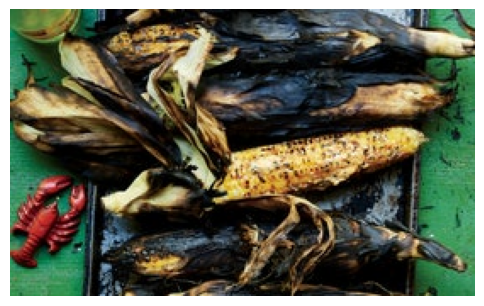

TITLE:
Mini egg cake

INGREDIENTS:
250g butter softened, plus a little extra, melted, for the tin | 250g self-raising flour plus extra for dusting | 225g golden caster sugar | 2 oranges zested | 5 large eggs | 1 tsp baking powder | 2 o

CAPTION:
mini egg cake made with 250g butter softened, plus a little extra, melted, for the tin | 250g self-raising flour plus extra for dusting | 225g golden caster sugar | 2 oranges zested | 5 large eggs | 1 tsp baking powder | 2 oranges juiced (use the ones you've zested) | 2 tbsp golden caster sugar | 150g butter softened | 500g icing sugar | 1 tsp vanilla extract | 180g tub full-fat cream cheese | 4 x


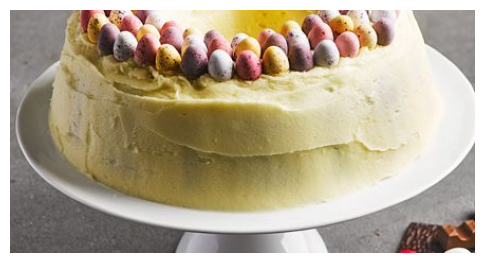

TITLE:
Steak and Eggs with Saucy Beans

INGREDIENTS:
['2 tsp. hot smoked Spanish paprika', '2 tsp. Aleppo-style pepper', '2 1/2 tsp. kosher salt, plus more', '1 tsp. freshly ground black pepper, plus more', '2 (1 1/4"-thick) boneless New York strip stea

CAPTION:
steak and eggs with saucy beans made with ['2 tsp. hot smoked spanish paprika', '2 tsp. aleppo-style pepper', '2 1/2 tsp. kosher salt, plus more', '1 tsp. freshly ground black pepper, plus more', '2 (1 1/4"-thick) boneless new york strip steaks (about 14 oz. each), patted dry', '7 tbsp. extra-virgin olive oil, divided', '2 medium shallots, finely chopped', '4 garlic cloves, thinly sliced', '1 smal


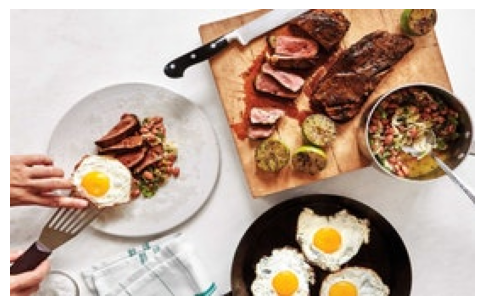

TITLE:
Sweet-and-Spicy Slaw

INGREDIENTS:
['1/2 cup apple cider vinegar', '6 Tbsp. peach nectar or juice', '1/4 cup extra-virgin olive oil', '2 Tbsp. vinegar-based hot sauce', '1/2 tsp. crushed red pepper flakes', '1/2 tsp. garlic powder', '1

CAPTION:
sweet-and-spicy slaw made with ['1/2 cup apple cider vinegar', '6 tbsp. peach nectar or juice', '1/4 cup extra-virgin olive oil', '2 tbsp. vinegar-based hot sauce', '1/2 tsp. crushed red pepper flakes', '1/2 tsp. garlic powder', '1/2 tsp. kosher salt', '1/4 tsp. cayenne pepper', '1/8 tsp. freshly ground black pepper', '1 large head of cabbage', 'thinly sliced']. whisk vinegar, peach nectar, oil, h


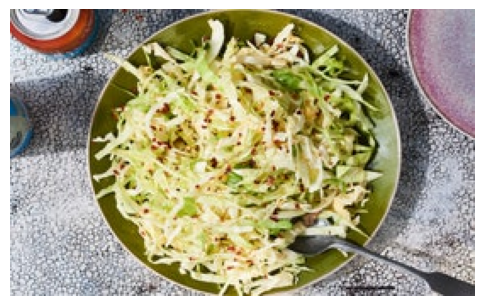

TITLE:
Whiskey sour

INGREDIENTS:
50ml bourbon | 35ml lemon juice | 12½ml 2:1 sugar syrup | 2 dashes bitters | ½ fresh egg white | ice | 50p-sized piece of lemon zest | slice of orange and a cherry on a stick

CAPTION:
whiskey sour made with 50ml bourbon | 35ml lemon juice | 12½ml 2:1 sugar syrup | 2 dashes bitters | ½ fresh egg white | ice | 50p-sized piece of lemon zest | slice of orange and a cherry on a stick. shake all of the ingredients (except for the lemon zest) hard with ice and strain into an ice-filled rocks glass. squeeze the lemon zest, shiny side down over the drink so the scented oils spray across


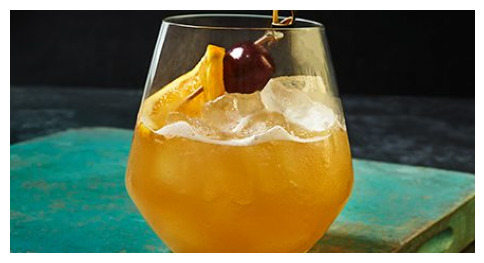

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# عدد عينات عشوائية
samples = 5

random_indices = random.sample(
    range(len(final_df)), # Changed from extract_path to final_df
    samples
)

for idx in random_indices:

    row = final_df.iloc[idx] # Changed from extract_path to final_df

    img_path = row["image_path"]

    caption = row["caption"]

    title = row["title"]

    ingredients = row["ingredients"]

    # load image
    img = Image.open(img_path)

    # show image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")

    print("="*60)

    print("TITLE:")
    print(title)

    print("\nINGREDIENTS:")
    print(ingredients[:200])

    print("\nCAPTION:")
    print(caption[:400])

    plt.show()

In [ ]:
# =========================================
# CAPTION REFINEMENT + AUGMENTATION
# FOR FOOD MENU DESCRIPTIONS
# =========================================

import pandas as pd
import random
import re

# ======================================================
# LOAD DATASET
# ======================================================

df = pd.read_csv(
    "/content/food_datatest/final_merged_food_dataset.csv"
)

print("DATASET SHAPE:", df.shape)


# ======================================================
# CLEAN TEXT FUNCTION
# ======================================================

def clean_text(text):

    text = str(text).lower()

    # remove weird symbols
    text = re.sub(r"[^a-zA-Z0-9 ,]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ======================================================
# SHORTEN INGREDIENTS
# ======================================================

def shorten_ingredients(ingredients, max_items=5):

    ingredients = str(ingredients).split("|")

    cleaned = []

    for item in ingredients[:max_items]:

        item = clean_text(item)

        # remove numbers
        item = re.sub(r"\d+", "", item)

        # remove measurements
        remove_words = [
            "g", "kg", "ml", "tbsp", "tsp",
            "cup", "cups", "oz", "fresh"
        ]

        words = item.split()

        words = [
            w for w in words
            if w not in remove_words
        ]

        item = " ".join(words)

        cleaned.append(item.strip())

    return cleaned


# ======================================================
# MENU STYLE TEMPLATES
# ======================================================

templates = [

    "Delicious {title} made with {ingredients}",

    "Freshly prepared {title} with {ingredients}",

    "Classic {title} served with {ingredients}",

    "Homemade {title} featuring {ingredients}",

    "Rich and flavorful {title} made with {ingredients}",

    "Authentic {title} prepared using {ingredients}",

    "Fresh {title} topped with {ingredients}",

    "Chef special {title} crafted with {ingredients}"
]


# ======================================================
# CREATE REFINED CAPTIONS
# ======================================================

new_captions = []

for idx, row in df.iterrows():

    title = clean_text(row["title"])

    ingredients = shorten_ingredients(
        row["ingredients"]
    )

    ingredients_text = ", ".join(ingredients)

    template = random.choice(templates)

    caption = template.format(
        title=title,
        ingredients=ingredients_text
    )

    # clean final caption
    caption = clean_text(caption)

    # add start/end tokens
    caption = "<start> " + caption + " <end>"

    new_captions.append(caption)


# ======================================================
# SAVE NEW CAPTIONS
# ======================================================

df["refined_caption"] = new_captions


# ======================================================
# REMOVE VERY SHORT CAPTIONS
# ======================================================

df = df[
    df["refined_caption"]
    .apply(lambda x: len(str(x).split()) > 5)
]


# ======================================================
# RESET INDEX
# ======================================================

df = df.reset_index(drop=True)


# ======================================================
# SAVE FINAL DATASET
# ======================================================

save_path = (

    "/content/final_refined_food_dataset.csv"

)

df.to_csv(save_path, index=False)

print("\nREFINED DATASET SAVED ✅")

print(save_path)


# ======================================================
# SHOW SAMPLES
# ======================================================

print("\nSAMPLES:\n")

for i in range(5):

    print("="*60)

    print("TITLE:")
    print(df["title"][i])

    print("\nREFINED CAPTION:")
    print(df["refined_caption"][i])

    print()

DATASET SHAPE: (21127, 7)

REFINED DATASET SAVED ✅
/content/final_refined_food_dataset.csv

SAMPLES:

TITLE:
Beer-battered pollock bites

REFINED CAPTION:
<start> authentic beer battered pollock bites prepared using pollock fillets, skinned and cut into bite size chunks, sunflower or vegetable oil, lime wedges, to serve, plain flour, frac golden caster sugar <end>

TITLE:
Cooking with kids: Spaghetti & meatballs with hidden veg sauce

REFINED CAPTION:
<start> delicious cooking with kids spaghetti meatballs with hidden veg sauce made with good quality pork sausage about large or chipolatas, lean beef mince, small onion coarsely grated, carrot finely grated, dried oregano <end>

TITLE:
Smoked mackerel with herb & beet couscous

REFINED CAPTION:
<start> rich and flavorful smoked mackerel with herb beet couscous made with couscous, horseradish sauce, pot fat greek yogurt, frac cucumber deseeded and cut into cubes, pack dill roughly chopped <end>

TITLE:
Mussels in white wine sauce with gar